# Info about СШАФК-10: Context & Content by https://www.kaggle.com/

Context
This dataset is only here for convenience. The original dataset in binary form can be found at https://www.cs.toronto.edu/~kriz/cifar.html
And the dataset in ImageNet format (each class is a subfolder) can be found at
https://course.fast.ai/datasets

Content
From the description on the dataset's home page,
"The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. Here are the classes in the dataset: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck "

Cover photo by Ethan McArthur on Unsplash https://www.kaggle.com/datasets/swaroopkml/cifar10-pngs-in-folders

In [1]:
#@title Step 0 Check GPU Status
import subprocess
simple_nvidia_smi_display = True#@param {type:"boolean"}
if simple_nvidia_smi_display:
    #!nvidia-smi
    nvidiasmi_output = subprocess.run(['nvidia-smi', '-L'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
else:
    #!nvidia-smi -i 0 -e 0
    nvidiasmi_output = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
    nvidiasmi_ecc_note = subprocess.run(['nvidia-smi', '-i', '0', '-e', '0'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_ecc_note)

GPU 0: Tesla T4 (UUID: GPU-c3112f8b-e7c2-2f1e-2761-67750a7c4920)



# Image Classification with CIFAR-10 Dataset and Scikit-Learn

In this notebook, we will explore the basics of image classification using the CIFAR-10 dataset and build a simple image classifier using Scikit-Learn. We will perform the following steps:
1. Load and preprocess the CIFAR-10 dataset.
2. Extract features from the images.
3. Train a machine learning model on the extracted features.
4. Evaluate the model's performance.

## Step 1: Installing and Importing Libraries

### Installing Libraries

Before we start, we need to ensure that we have all the necessary libraries installed. We can use `!pip install` to install any missing libraries directly from the Jupyter Notebook. This command is useful for installing Python packages from the Python Package Index (PyPI).

### Why Install Libraries?

Libraries provide pre-written code that we can use to perform various tasks without having to write everything from scratch. Installing libraries ensures we have access to the necessary functions and tools needed for our project.

Here are the libraries we need for this notebook:
- **numpy:** For numerical operations.
- **matplotlib:** For plotting and visualizing images.
- **tensorflow:** For loading the CIFAR-10 dataset.
- **scikit-learn (sklearn):** For machine learning models and evaluation metrics.

### Installing Libraries Individually vs. All at Once


You can install each library separately by writing a `!pip install` command for each library. This looks like:
```python
!pip install numpy
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn


Alternatively, you can install all the libraries together in a single !pip install command by separating the library names with a space

!pip install numpy matplotlib tensorflow scikit-learn

## Differences and Considerations
- **Convenience**: Installing all libraries at once is more convenient and requires fewer lines of code. It can save time when writing and running the notebook.
- **Execution Time**: Running a single !pip install command can be faster than running multiple commands, as it reduces the overhead of initiating separate installation processes for each library.
- **Dependency Management**: Installing libraries together can help Pip resolve dependencies more efficiently, potentially avoiding conflicts that might arise when installing libraries separately.
- **Debugging**: Installing libraries individually can make it easier to identify which specific library caused an issue if an installation error occurs. However, this is generally only a concern if you encounter frequent installation problems.

For this notebook, we will install all necessary libraries together for convenience.

In [2]:
!pip install numpy matplotlib tensorflow scikit-learn


### Importing Libraries

After installing the libraries, we need to import them into our notebook. Importing libraries allows us to use their functionalities in our code. Each library is imported using an alias (short name) to make the code cleaner and more readable.

Let's import the required libraries:


In [3]:
#@title Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


In [8]:
#@title Importing MY necessary libraries for extra-home-work
from google.colab import drive #work with Google Drive
import zipfile #Extract one ZIP archive form www.kaggle.com downloaded to Google Drive to local Colab storage.
import os #folder paths on GoogleDrive
import tensorflow as tf #For loading images
import pandas as pd # Used to create tables for class distribution stats (but I guess I could have done without it)
import time #to compare training times using color and grayscale images

## Step 2: Loading and Preprocessing the CIFAR-10 Dataset

The CIFAR-10 dataset is readily available in the `keras` library. We will load the dataset and preprocess it by converting the images to grayscale and flattening them.


In [5]:
#@title I didn't run this cell
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# To minimize computational demands lets work with three classes of your choice

# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# Choose a subset of classes
chosen_classes = ['cat', 'dog', 'ship']
class_indices = [class_names.index(cls) for cls in chosen_classes]

   548864/170498071 ━━━━━━━━━━━━━━━━━━━━ 29:44 10us/step

KeyboardInterrupt: 

👆 I won't use the code from the cell above

The file took a very long time to load (around 1 hour), so I optimized it by uploading the file from the dataset https://www.kaggle.com/datasets/swaroopkml/cifar10-pngs-in-folders/data to my Google Drive and working with it directly.

The code below replaces the previous code block:

In [9]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Datasets/cifar10.zip'
extract_to = '/content/cifar_data/'

if not os.path.exists(extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Success unpack!")
else:
    print("Was unpack before")


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
chosen_classes = ['airplane', 'bird', 'ship']
class_indices = [class_names.index(cls) for cls in chosen_classes]

print(os.listdir('/content/cifar_data/'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Was unpack before
['cifar10']


In [10]:
print(os.listdir('/content/cifar_data/cifar10/'))

['cifar10']


In [11]:
print(os.listdir('/content/cifar_data/cifar10/cifar10/'))

['train', 'test']


👆 In the bottom cells you can see how the folders were duplicated when the archive was extracted.
I have no idea how this happened, but I'll leave it as is

In [12]:
# My Google Drive directories
base_path = '/content/cifar_data/cifar10/cifar10/train'
train_dir = '/content/cifar_data/cifar10/cifar10/train'
test_dir = '/content/cifar_data/cifar10/cifar10/test'

# 1. Download train
train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=(32, 32), batch_size=50000, shuffle=False)
for X_all, y_all in train_ds:
    X_train = X_all.numpy().astype(np.uint8)
    y_train = y_all.numpy().reshape(-1, 1)

# 2. Download test
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=(32, 32), batch_size=10000, shuffle=False)
for X_all, y_all in test_ds:
    X_test = X_all.numpy().astype(np.uint8)
    y_test = y_all.numpy().reshape(-1, 1)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


### 👆 I want to make sure the dataset has loaded by viewing 9 random images from it

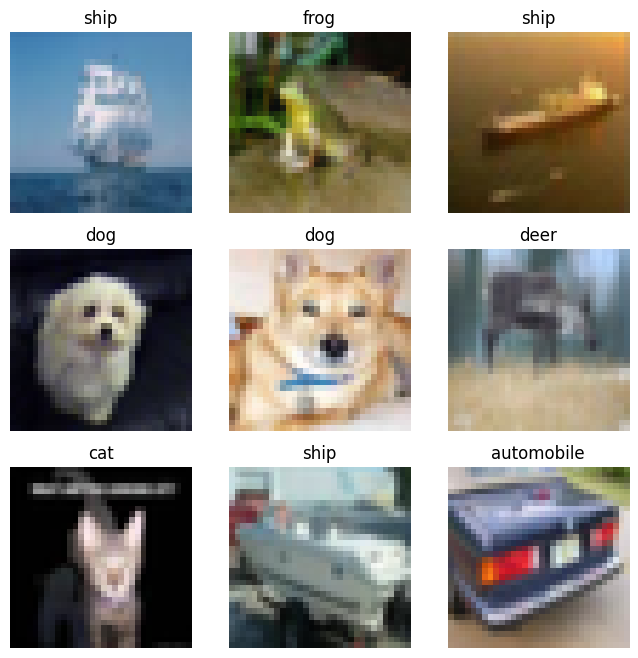

In [13]:
#@title Visual check of correct code execution: 9 random color images in dataset
# 3. Random 9 pic from dataset: every restart = new 9 images
indices = np.random.choice(X_train.shape[0], size=9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[indices[i]])

    label_idx = y_train[indices[i]][0]
    ax.set_title(class_names[label_idx])
    ax.axis('off')
plt.show()

👆 Is the eighth image a car or a ship?

In [18]:
# Filter data for the chosen classes
mask_train = np.isin(y_train, class_indices)
mask_test = np.isin(y_test, class_indices)
X_train_subset = X_train[mask_train.flatten()]
y_train_subset = y_train[mask_train]
X_test_subset = X_test[mask_test.flatten()]
y_test_subset = y_test[mask_test]

###I want to visually verify once again that the correct classes were loaded, using 9 random images as an example

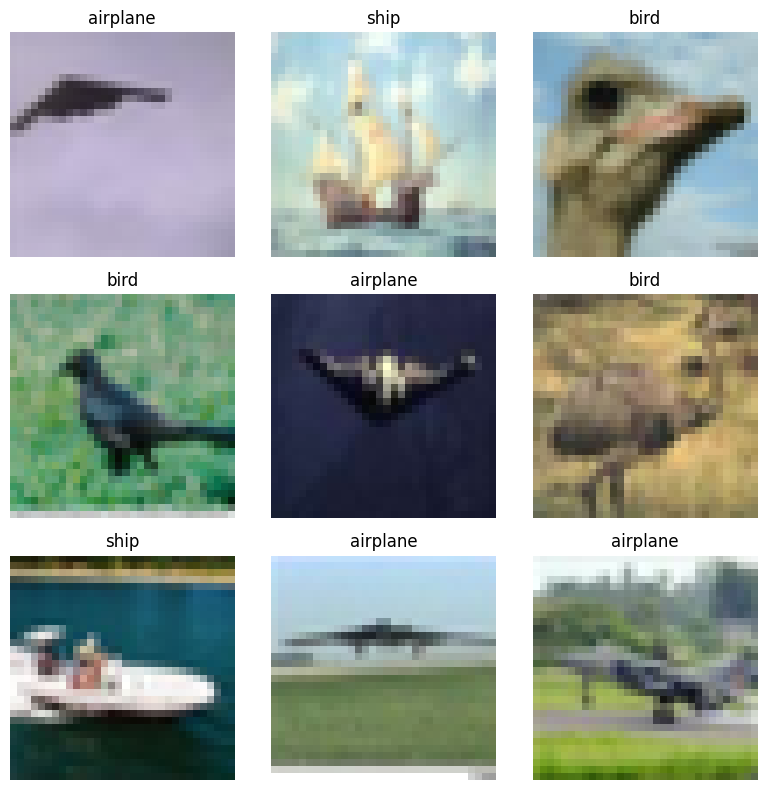

In [19]:
#@title Visual check of correct code execution: 9 random color images in classes
indices = np.random.choice(X_train_subset.shape[0], size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

# 3. Random 9 pic from dataset: every restart = new 9 images
indices = np.random.choice(X_train_subset.shape[0], size=9, replace=False)


for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(X_train_subset[idx])

    label_val = y_train_subset[idx]
    if isinstance(label_val, (list, np.ndarray)):
        label_val = label_val[0]
    label_idx = int(label_val)

    ax.set_title(class_names[label_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Convert images to grayscale
X_train_gray = np.dot(X_train_subset[...,:3], [0.2989, 0.5870, 0.1140])
X_test_gray = np.dot(X_test_subset[...,:3], [0.2989, 0.5870, 0.1140])

# Normalize the images
X_train_normalized = X_train_gray / 255.0
X_test_normalized = X_test_gray / 255.0

# Flatten the images
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)




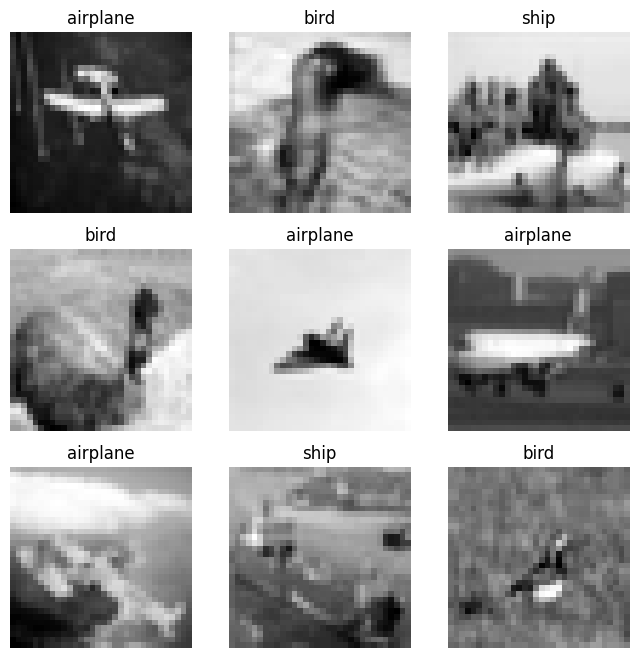

Training set size: (15000, 1024)
Testing set size: (3000, 1024)


In [17]:
#@title Visual check of correct code execution: 9 random grayscale images in classes
# Display a sample 1 image -> Display a grayscale 9 images
indices = np.random.choice(X_train_gray.shape[0], size=9, replace=False) #Generate random idexes

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    # Take Random index
    idx = indices[i]
    ax.imshow(X_train_gray[idx], cmap='gray')

    label_val = y_train_subset[idx]
    label_idx = int(label_val[0] if isinstance(label_val, (list, np.ndarray)) else label_val)
    ax.set_title(class_names[label_idx])
    ax.axis('off')
plt.show()

print("Training set size:", X_train_flat.shape)
print("Testing set size:", X_test_flat.shape)

## Step 3: Training a Machine Learning Model

### What is SVM (Support Vector Machine)?

Support Vector Machine (SVM) is a supervised machine learning algorithm that can be used for both classification and regression tasks. However, it is mostly used for classification problems. The objective of the SVM algorithm is to find a hyperplane in an N-dimensional space (N is the number of features) that distinctly classifies the data points.

### Key Concepts:

- **Hyperplane:** A decision boundary that separates different classes in the feature space. In 2D, it's a line; in 3D, it's a plane.
- **Support Vectors:** Data points that are closest to the hyperplane and influence its position and orientation. These points help in maximizing the margin of the classifier.
- **Margin:** The distance between the hyperplane and the closest data points from either class. SVM aims to maximize this margin.

### Why Use SVM?

- **Effective in high-dimensional spaces:** SVM is very effective when the number of features is large.
- **Memory efficient:** It uses a subset of training points (support vectors) in the decision function, making it memory efficient.
- **Versatile:** Different kernel functions can be specified for the decision function. Common kernels include linear, polynomial, and radial basis function (RBF).

### What does `SVC(kernel='linear')` mean?

`SVC` stands for Support Vector Classification, which is a class in the Scikit-Learn library used to implement the SVM algorithm for classification tasks. The `kernel` parameter in the `SVC` class specifies the type of hyperplane used to separate the data.

#### Kernel Types:

- **Linear Kernel:** The data is linearly separable (i.e., a straight line or hyperplane can separate the data). This is the simplest kernel.
  - When we use `SVC(kernel='linear')`, it means we are using a linear kernel for our SVM. This kernel is appropriate when the data can be separated by a straight line (or hyperplane in higher dimensions).
- **Polynomial Kernel:** The data is not linearly separable, but a polynomial function of the input features can separate the data.
- **Radial Basis Function (RBF) Kernel:** The data is not linearly separable, but mapping the data into a higher-dimensional space using a Gaussian (RBF) function can separate the data.

### Training the SVM Model

We will use a Support Vector Machine (SVM) classifier from Scikit-Learn to train our model on the extracted features.


In [20]:
#@title How many grayscale images do we use for training?

train_counts = pd.Series(y_train_subset.flatten()).value_counts().sort_index()
test_counts = pd.Series(y_test_subset.flatten()).value_counts().sort_index()
stats_df = pd.DataFrame({
    'Class Name': chosen_classes,
    'Train Count': train_counts.values,
    'Test Count': test_counts.values
})

print(stats_df)

  Class Name  Train Count  Test Count
0   airplane         5000        1000
1       bird         5000        1000
2       ship         5000        1000


In [21]:
# Train an SVM classifier
model = SVC(kernel='linear', verbose=True) #+ logs, but logs didnt works
model.fit(X_train_flat, y_train_subset.ravel())

# Predict on the test set
y_pred = model.predict(X_test_flat)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_subset, y_pred))
print("Classification Report:\n", classification_report(y_test_subset, y_pred, target_names=chosen_classes))




[LibSVM]Accuracy: 0.5366666666666666
Classification Report:
               precision    recall  f1-score   support

    airplane       0.47      0.43      0.45      1000
        bird       0.54      0.57      0.55      1000
        ship       0.58      0.61      0.60      1000

    accuracy                           0.54      3000
   macro avg       0.53      0.54      0.53      3000
weighted avg       0.53      0.54      0.53      3000



👆 The model was trained for 4 minutes on grayscale images. I'm curious how long it would train on color images.

In [ ]:
model = SVC(kernel='linear', verbose=True)
model.fit(X_train_subset.reshape(len(X_train_subset), -1), y_train_subset.ravel())

# Predict on the test set
# We use X_test_subset.reshape(len(X_test_subset), -1) to flatten the color test data
y_pred = model.predict(X_test_subset.reshape(len(X_test_subset), -1))

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_subset, y_pred))
print("Classification Report:\n", classification_report(y_test_subset, y_pred, target_names=chosen_classes))

[LibSVM]

👆 I waited about an hour, but this block of code did not execute. Maybe GoogleColab logged me out because my session was inactive, or maybe it’s because training on color images really does take a long time. I’ll run a more realistic experiment using 999 images.

One more little experiment: I want to see, using a small training dataset of 999 records, how training on color images differs from training on grayscale image:

In [25]:
#@title Comparison of learning rates for 999 color Images and 999 grayscale images
# Take 333 images for every class, total is exactly 999
n_per_class = 333
indices = []

for cls in np.unique(y_train_subset):
    # Find all index positions for this class
    cls_indices = np.where(y_train_subset == cls)[0]
    # Take the first 333 images
    indices.extend(cls_indices[:n_per_class])

# Shuffle index list for good results
np.random.shuffle(indices)

# Prepare data for training
X_rgb_subset = X_train_subset[indices].reshape(len(indices), -1)
X_gray_subset = X_train_gray[indices].reshape(len(indices), -1)
y_subset = y_train_subset[indices].ravel()

X_rgb_test = X_test_subset.reshape(len(X_test_subset), -1)
X_gray_test = X_test_gray.reshape(len(X_test_gray), -1)

# 1. Train with color (RGB)
start_time = time.time()
model_rgb = SVC(kernel='linear', random_state=42)
model_rgb.fit(X_rgb_subset, y_subset)
rgb_time = time.time() - start_time
y_pred_rgb = model_rgb.predict(X_rgb_test)
rgb_acc = accuracy_score(y_test_subset, y_pred_rgb)
print("Color: time =", round(rgb_time, 2), "s, accuracy =", round(rgb_acc, 2))

# 2. Train with gray images
start_time = time.time()
model_gray = SVC(kernel='linear', random_state=42)
model_gray.fit(X_gray_subset, y_subset)
gray_time = time.time() - start_time
y_pred_gray = model_gray.predict(X_gray_test)
gray_acc = accuracy_score(y_test_subset, y_pred_gray)
print("Gray:  time =", round(gray_time, 2), "s, accuracy =", round(gray_acc, 2))

Color: time = 1.68 s, accuracy = 0.55
Gray:  time = 2.33 s, accuracy = 0.44


👆 It's strange, but speed difference isn't very big here, but RGB contains three times (3 color channels) as much information as grayscale. Maybe I made a mistake in the extra experiment's code. On the other hand, we can see that training on colored models improves accuracy

## I'm curious how long it would train with sklearn vs TensorFlow vs YOLO: but not today pls ;-)

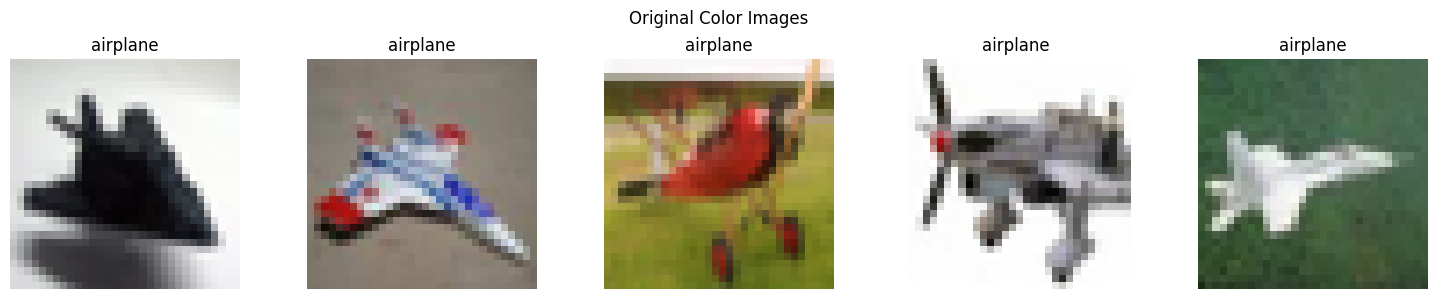

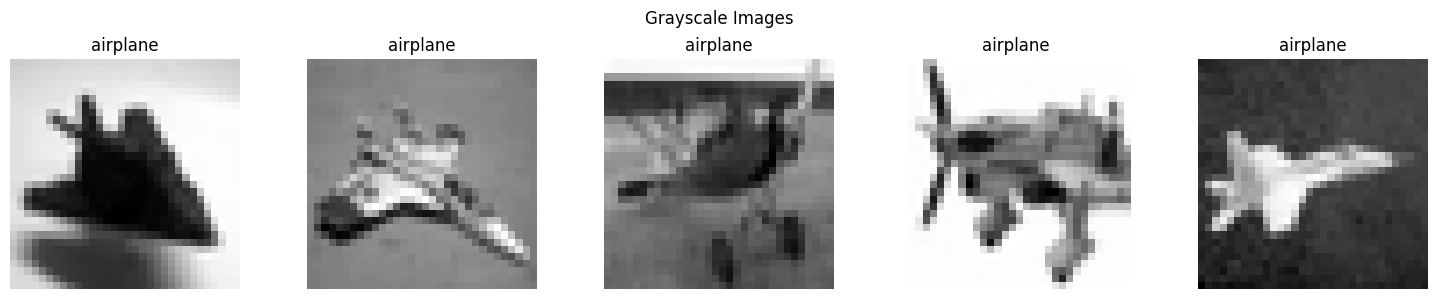

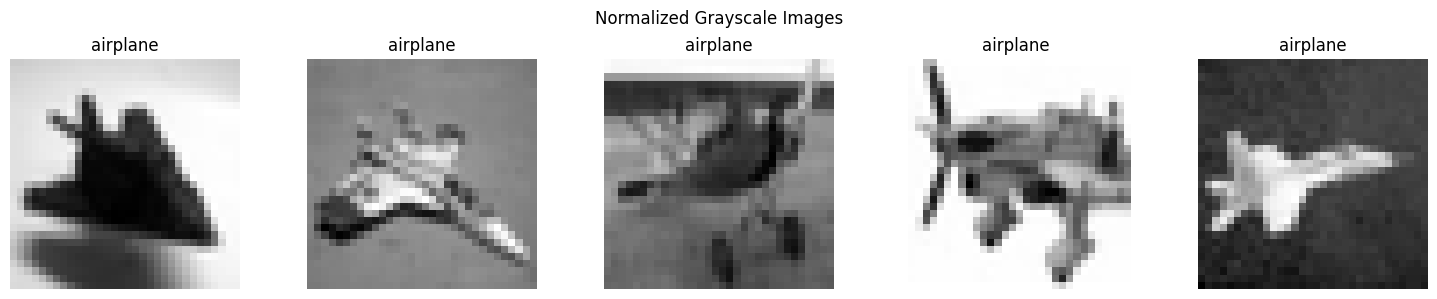

In [24]:
#@title Lets see some images of the  datasset in the different stages
# Function to display images
def display_images(images, titles, main_title, cmap=None):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(main_title)
    for i, ax in enumerate(axes):
        if cmap:
            ax.imshow(images[i], cmap=cmap)
        else:
            ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Display original color images
display_images(X_train_subset[:5],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:5]],
               'Original Color Images')

# Display grayscale images
display_images(X_train_gray[:5],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:5]],
               'Grayscale Images', cmap='gray')

# Display normalized images
display_images(X_train_normalized[:5],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:5]],
               'Normalized Grayscale Images', cmap='gray')

In [26]:
# Experiment: Test different SVM kernels and hyperparameters
print("Testing different kernels on grayscale data...")

# 1. RBF Kernel (Radial Basis Function)
start_time = time.time()
# C is a hyperparameter. gamma='scale' is default but good to show.
model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_rbf.fit(X_gray_subset, y_subset)
pred_rbf = model_rbf.predict(X_gray_test)
acc_rbf = accuracy_score(y_test_subset, pred_rbf)
print("RBF Kernel: time =", round(time.time() - start_time, 2), "s, accuracy =", round(acc_rbf, 2))

# 2. Polynomial Kernel
start_time = time.time()
# degree=3 is a hyperparameter for poly kernel
model_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
model_poly.fit(X_gray_subset, y_subset)
pred_poly = model_poly.predict(X_gray_test)
acc_poly = accuracy_score(y_test_subset, pred_poly)
print("Poly Kernel: time =", round(time.time() - start_time, 2), "s, accuracy =", round(acc_poly, 2))

Testing different kernels on grayscale data...
RBF Kernel: time = 6.67 s, accuracy = 0.63
Poly Kernel: time = 1.82 s, accuracy = 0.56


👆 We test RBF and Polynomial kernels on our grayscale data. We want to see how different parameters (`C`, `gamma`, `degree`) change model accuracy and training time.

## Step 4: Conclusion

In this notebook, we:
1. Loaded and preprocessed the CIFAR-10 dataset.
2. Converted the images to grayscale and flattened them to use as features.
3. Trained an SVM classifier on the extracted features.
4. Evaluated the model's performance.

### Summary of SVM

Support Vector Machines (SVM) are a powerful tool for classification tasks. They work by finding the optimal hyperplane that maximizes the margin between different classes. The key points include:
- **Hyperplane:** The decision boundary.
- **Support Vectors:** Critical data points that define the hyperplane.
- **Margin:** The gap between the hyperplane and the nearest data points from any class.

SVMs are effective in high-dimensional spaces and are versatile due to the use of different kernel functions. However, they can be computationally intensive for large datasets and less effective for overlapping classes.

This exercise provided a basic introduction to image classification using classical machine learning techniques. Next  few modules will explore advanced applications, using deep learning models like Convolutional Neural Networks (CNNs) using libraries such as TensorFlow or PyTorch.


## Step 4.1: Conclusion: My Reflection Journal

In this notebook, we performed a deep exploration of image classification using Support Vector Machines (SVM). Our key steps were:
* Researched dataset details on Kaggle and optimized loading by using a ZIP archive stored on Google Drive.
* Implemented a full SVM classification pipeline, including data preprocessing, grayscale conversion, and image flattening + Visual check to verify correct code execution:
* Added 3 visual verification steps (displaying 9 random images for datasets and specific classes color and grayscale) to ensure data integrity.
* Trained an SVM classifier on extracted features and evaluated performance.

**Experiments and Observations:**
* We compared training performance between grayscale and color images. While grayscale is faster, color images provide more information.
* A small-scale experiment (999 images) confirmed that training on color data is computationally more demanding.
* We utilized T4 GPU acceleration to manage training times, noting that for larger datasets, a local high-performance workstation would be more efficient.
* The model achieved an accuracy of 0.54, which serves as a solid baseline for classical machine learning.


**Reflection and Future Work:**
My next goal is to compare the performance and training efficiency of this approach vs TensorFlow vs YOLO. I plan to run these resource-intensive computations on my local computer to avoid the time constraints associated with using cloud services. Also, I've seen that the time it spends on lab work is increasing, so it looks like I'll have to switch from the T4 card to my RTX 5090 after all.